# Early Fusion - Binary Sentiment Classification

## Overview
This notebook implements **Early Fusion** (also called **Feature-level Fusion**) for multimodal sentiment analysis.

## Early Fusion vs Tensor Fusion

### Early Fusion (This Notebook)
```
Text Features → LSTM → z_text (128)
Video Features → LSTM → z_video (128)     →  CONCATENATE  →  Classifier
Audio Features → LSTM → z_audio (128)

Concatenated: [z_text; z_video; z_audio] = 384 dimensions
```

**Pros:**
- Simple and fast
- Much lower dimensionality (384 vs 35,937)
- Fewer parameters
- Faster training

**Cons:**
- Linear combination only
- Cannot capture cross-modal interactions
- Treats modalities independently

### Tensor Fusion (Previous Notebook)
```
Text Features → LSTM → z_text (32)
Video Features → LSTM → z_video (32)     →  OUTER PRODUCT  →  Classifier
Audio Features → LSTM → z_audio (32)

Tensor Fusion: [1;z_t] ⊗ [1;z_v] ⊗ [1;z_a] = 35,937 dimensions
```

**Pros:**
- Captures all cross-modal interactions
- Bimodal and trimodal feature combinations
- More expressive representation

**Cons:**
- Exponential dimensionality growth
- More parameters (19M vs ~0.5M)
- Slower training
- Memory intensive

### Expected Results
- **Early Fusion**: Fast baseline, ~70-74% accuracy
- **Tensor Fusion**: Better performance, ~76% accuracy
- Goal: Demonstrate that tensor fusion's complexity is justified by performance gain

In [1]:
import os
# Change to MultiBench directory
os.chdir('MultiBench')

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("✓ Libraries imported successfully")

h:\Programs\Anaconda\envs\multimodal\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries imported successfully


In [3]:
# Load all three modalities
with open('data/exported_modalities/mosi_text.pkl', 'rb') as f:
    text_data = pickle.load(f)

with open('data/exported_modalities/mosi_vision.pkl', 'rb') as f:
    video_data = pickle.load(f)

with open('data/exported_modalities/mosi_audio.pkl', 'rb') as f:
    audio_data = pickle.load(f)

print("EARLY FUSION: TEXT + VIDEO + AUDIO")
print("="*70)
print("\nData Shapes:")
print(f"  Text:  {text_data['train']['data'].shape}  (300-dim GloVe)")
print(f"  Video: {video_data['train']['data'].shape}  (35-dim Facet)")
print(f"  Audio: {audio_data['train']['data'].shape}  (74-dim COVAREP)")

# Convert to binary labels
def convert_to_binary(labels):
    return (labels > 0).astype(np.float32).flatten()

train_labels_binary = convert_to_binary(text_data['train']['labels'])
valid_labels_binary = convert_to_binary(text_data['valid']['labels'])
test_labels_binary = convert_to_binary(text_data['test']['labels'])

print("\nBinary Label Distribution:")
print("="*70)
for split_name, labels in [('TRAIN', train_labels_binary), 
                            ('VALID', valid_labels_binary), 
                            ('TEST', test_labels_binary)]:
    pos = int(labels.sum())
    neg = int(len(labels) - pos)
    print(f"{split_name:<10} Positive (1): {pos:<5} | Negative (0): {neg:<5} | Ratio: {pos/(pos+neg):.2f}")

# Clean data
def clean_data(data):
    return np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

for split in ['train', 'valid', 'test']:
    text_data[split]['data'] = clean_data(text_data[split]['data'])
    video_data[split]['data'] = clean_data(video_data[split]['data'])
    audio_data[split]['data'] = clean_data(audio_data[split]['data'])

print("\n✓ Data loaded and cleaned")

EARLY FUSION: TEXT + VIDEO + AUDIO

Data Shapes:
  Text:  (1283, 50, 300)  (300-dim GloVe)
  Video: (1283, 50, 35)  (35-dim Facet)
  Audio: (1283, 50, 74)  (74-dim COVAREP)

Binary Label Distribution:
TRAIN      Positive (1): 678   | Negative (0): 605   | Ratio: 0.53
VALID      Positive (1): 123   | Negative (0): 91    | Ratio: 0.57
TEST       Positive (1): 277   | Negative (0): 409   | Ratio: 0.40

✓ Data loaded and cleaned

✓ Data loaded and cleaned


In [4]:
# Create PyTorch datasets
train_dataset = TensorDataset(
    torch.FloatTensor(text_data['train']['data']),
    torch.FloatTensor(video_data['train']['data']),
    torch.FloatTensor(audio_data['train']['data']),
    torch.FloatTensor(train_labels_binary)
)
valid_dataset = TensorDataset(
    torch.FloatTensor(text_data['valid']['data']),
    torch.FloatTensor(video_data['valid']['data']),
    torch.FloatTensor(audio_data['valid']['data']),
    torch.FloatTensor(valid_labels_binary)
)
test_dataset = TensorDataset(
    torch.FloatTensor(text_data['test']['data']),
    torch.FloatTensor(video_data['test']['data']),
    torch.FloatTensor(audio_data['test']['data']),
    torch.FloatTensor(test_labels_binary)
)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ DataLoaders created (batch_size={batch_size})")

✓ DataLoaders created (batch_size=32)


In [5]:
# Early Fusion Model - Simple Concatenation
class EarlyFusionModel(nn.Module):
    """
    Early Fusion Model for Multimodal Sentiment Analysis.
    
    Architecture:
    1. Process each modality with separate LSTMs
    2. CONCATENATE the outputs
    3. Pass through classifier
    
    Key Difference from Tensor Fusion:
    - Concatenation: [z_t; z_v; z_a] → Linear combination
    - Tensor Fusion: z_t ⊗ z_v ⊗ z_a → Captures interactions
    """
    
    def __init__(self, text_input_dim=300, video_input_dim=35, audio_input_dim=74,
                 hidden_dim=128, dropout=0.2):
        super(EarlyFusionModel, self).__init__()
        
        self.hidden_dim = hidden_dim
        
        # Text Encoder
        self.text_lstm = nn.LSTM(text_input_dim, hidden_dim, batch_first=True)
        self.text_ln = nn.LayerNorm(hidden_dim)
        
        # Video Encoder
        self.video_lstm = nn.LSTM(video_input_dim, hidden_dim, batch_first=True)
        self.video_ln = nn.LayerNorm(hidden_dim)
        
        # Audio Encoder
        self.audio_lstm = nn.LSTM(audio_input_dim, hidden_dim, batch_first=True)
        self.audio_ln = nn.LayerNorm(hidden_dim)
        
        # Fusion dimension: concatenated features
        fusion_dim = hidden_dim * 3  # 128 * 3 = 384 dimensions
        
        # Classifier (much simpler than tensor fusion)
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if 'weight_ih' in name:
                        nn.init.xavier_uniform_(param.data)
                    elif 'weight_hh' in name:
                        nn.init.orthogonal_(param.data)
                    elif 'bias' in name:
                        nn.init.zeros_(param.data)
    
    def forward(self, text_input, video_input, audio_input):
        """
        Forward pass with early fusion.
        
        Args:
            text_input: (batch, seq_len, 300)
            video_input: (batch, seq_len, 35)
            audio_input: (batch, seq_len, 74)
        
        Returns:
            Binary prediction: (batch,)
        """
        # Process each modality
        text_lstm_out, (text_h, _) = self.text_lstm(text_input)
        text_h = self.text_ln(text_h[-1])  # (batch, 128)
        
        video_lstm_out, (video_h, _) = self.video_lstm(video_input)
        video_h = self.video_ln(video_h[-1])  # (batch, 128)
        
        audio_lstm_out, (audio_h, _) = self.audio_lstm(audio_input)
        audio_h = self.audio_ln(audio_h[-1])  # (batch, 128)
        
        # EARLY FUSION: Simple concatenation
        fused = torch.cat([text_h, video_h, audio_h], dim=1)  # (batch, 384)
        
        # Classification
        output = self.classifier(fused).squeeze()  # (batch,)
        
        return output

# Initialize model
device = torch.device('cpu')
model = EarlyFusionModel(text_input_dim=300, video_input_dim=35, audio_input_dim=74,
                         hidden_dim=128, dropout=0.2)
model = model.to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01, betas=(0.9, 0.999))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, 
                                                  patience=5, verbose=True, min_lr=1e-6)

print("="*70)
print("EARLY FUSION MODEL INITIALIZED")
print("="*70)
print(f"Device: {device}")
print(f"\nArchitecture:")
print(f"  Text LSTM:  300 → 128")
print(f"  Video LSTM: 35 → 128")
print(f"  Audio LSTM: 74 → 128")
print(f"  Fusion: CONCATENATE [text; video; audio] = 384 dims")
print(f"  Classifier: 384 → 256 → 128 → 64 → 1")
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nCompare with Tensor Fusion:")
print(f"  Early Fusion:  384 dimensions, ~500K params")
print(f"  Tensor Fusion: 35,937 dimensions, ~19M params")
print(f"  Ratio: 93x fewer dimensions, 38x fewer parameters")
print("="*70)

EARLY FUSION MODEL INITIALIZED
Device: cpu

Architecture:
  Text LSTM:  300 → 128
  Video LSTM: 35 → 128
  Audio LSTM: 74 → 128
  Fusion: CONCATENATE [text; video; audio] = 384 dims
  Classifier: 384 → 256 → 128 → 64 → 1

Total Parameters: 550,529

Compare with Tensor Fusion:
  Early Fusion:  384 dimensions, ~500K params
  Tensor Fusion: 35,937 dimensions, ~19M params
  Ratio: 93x fewer dimensions, 38x fewer parameters


In [6]:
# Model Summary - Early Fusion Architecture
print("="*80)
print("EARLY FUSION MODEL - ARCHITECTURE SUMMARY")
print("="*80)

try:
    from torchinfo import summary
    
    # Use smaller batch size for summary
    batch_size_summary = 2
    text_seq_len = 50
    video_seq_len = 50
    audio_seq_len = 50
    text_input_dim = 300
    video_input_dim = 35
    audio_input_dim = 74
    
    print("\nGenerating detailed model summary with torchinfo...\n")
    
    # Create summary with multiple inputs (text, video, audio)
    summary(model, 
            input_size=[(batch_size_summary, text_seq_len, text_input_dim),
                       (batch_size_summary, video_seq_len, video_input_dim),
                       (batch_size_summary, audio_seq_len, audio_input_dim)],
            device=str(device),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            row_settings=["var_names"],
            verbose=1)
    
except ImportError:
    print("\n⚠️  torchinfo not installed. Install with: pip install torchinfo")
    print("\nShowing manual parameter breakdown instead:\n")
    
    total_params = 0
    trainable_params = 0
    
    print("="*80)
    print("PARAMETER BREAKDOWN BY SUBNETWORK")
    print("="*80)
    
    # Text Subnetwork
    text_params = sum(p.numel() for p in model.text_lstm.parameters()) + \
                  sum(p.numel() for p in model.text_ln.parameters())
    print(f"\n1. TEXT ENCODER (LSTM + LayerNorm)")
    print(f"   - Text LSTM (300 → 128):        {sum(p.numel() for p in model.text_lstm.parameters()):>12,} params")
    print(f"   - Text LayerNorm:                {sum(p.numel() for p in model.text_ln.parameters()):>12,} params")
    print(f"   {'SUBTOTAL:':<35} {text_params:>12,} params")
    
    # Video Subnetwork
    video_params = sum(p.numel() for p in model.video_lstm.parameters()) + \
                   sum(p.numel() for p in model.video_ln.parameters())
    print(f"\n2. VIDEO ENCODER (LSTM + LayerNorm)")
    print(f"   - Video LSTM (35 → 128):         {sum(p.numel() for p in model.video_lstm.parameters()):>12,} params")
    print(f"   - Video LayerNorm:               {sum(p.numel() for p in model.video_ln.parameters()):>12,} params")
    print(f"   {'SUBTOTAL:':<35} {video_params:>12,} params")
    
    # Audio Subnetwork
    audio_params = sum(p.numel() for p in model.audio_lstm.parameters()) + \
                   sum(p.numel() for p in model.audio_ln.parameters())
    print(f"\n3. AUDIO ENCODER (LSTM + LayerNorm)")
    print(f"   - Audio LSTM (74 → 128):         {sum(p.numel() for p in model.audio_lstm.parameters()):>12,} params")
    print(f"   - Audio LayerNorm:               {sum(p.numel() for p in model.audio_ln.parameters()):>12,} params")
    print(f"   {'SUBTOTAL:':<35} {audio_params:>12,} params")
    
    # Fusion Layer
    fusion_dim = model.hidden_dim * 3
    print(f"\n4. EARLY FUSION LAYER (Concatenation)")
    print(f"   - Operation: CONCATENATE [z_t; z_v; z_a]")
    print(f"   - Input dims: 128 + 128 + 128")
    print(f"   - Output dims: {fusion_dim}")
    print(f"   - Parameters:                    {0:>12,} params  ← PARAMETER-FREE!")
    
    # Classifier
    classifier_params = sum(p.numel() for p in model.classifier.parameters())
    print(f"\n5. CLASSIFIER (Sentiment Prediction)")
    print(f"   - MLP: {fusion_dim} → 256 → 128 → 64 → 1")
    print(f"   - Total parameters:              {classifier_params:>12,} params")
    
    total_params = text_params + video_params + audio_params + classifier_params
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("\n" + "="*80)
    print(f"TOTAL PARAMETERS:                    {total_params:>12,}")
    print(f"TRAINABLE PARAMETERS:                {trainable_params:>12,}")
    print(f"MODEL SIZE (approx):                 {total_params * 4 / (1024**2):>11.2f} MB")
    print("="*80)

print("\n" + "="*80)
print("ARCHITECTURE FLOW - EARLY FUSION")
print("="*80)
print("""
Input Data:
  ├─ Text:  (batch, 50, 300)  [GloVe embeddings]
  ├─ Video: (batch, 50, 35)   [Facet features]
  └─ Audio: (batch, 50, 74)   [COVAREP features]
       │
       ├──────────────────┬──────────────────┬──────────────────┐
       │                  │                  │                  │
  Text LSTM          Video LSTM         Audio LSTM         (Encode sequences)
  (300→128)          (35→128)           (74→128)
       │                  │                  │
  LayerNorm          LayerNorm          LayerNorm          (Normalize)
       │                  │                  │
    z_text             z_video            z_audio          (Unimodal features)
    (128-dim)          (128-dim)          (128-dim)
       │                  │                  │
       └──────────────────┴──────────────────┘
                          │
                 CONCATENATION                              (Early fusion)
                 [z_t; z_v; z_a]                           (Parameter-free)
                 384 dimensions
                          │
                    Classifier MLP                          (Sentiment prediction)
                 384 → 256 → 128 → 64 → 1
                          │
                   Sigmoid Activation
                          │
                 Binary Prediction (0 or 1)

Key Features:
  ✓ Three independent unimodal encoders (Text, Video, Audio)
  ✓ Simple concatenation fusion (linear combination)
  ✓ Parameter-free fusion operation
  ✓ Much simpler than tensor fusion (384 vs 35,937 dims)
  ✓ Total: {total_params:,} parameters
  ✓ 38x fewer parameters than Tensor Fusion

Comparison with Tensor Fusion:
  Early Fusion:
    - Method: CONCATENATION [z_t; z_v; z_a]
    - Dimensions: 384
    - Parameters: ~500K
    - Captures: Linear combinations of modalities
    
  Tensor Fusion:
    - Method: OUTER PRODUCT [1;z_t] ⊗ [1;z_v] ⊗ [1;z_a]
    - Dimensions: 35,937
    - Parameters: ~19M
    - Captures: All cross-modal interactions (unimodal, bimodal, trimodal)
""")
print("="*80)

print("\n✓ Model summary complete!")
print("  Install torchinfo for detailed layer-by-layer analysis:")
print("  pip install torchinfo")


EARLY FUSION MODEL - ARCHITECTURE SUMMARY

Generating detailed model summary with torchinfo...

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
EarlyFusionModel (EarlyFusionModel)      [2, 50, 300]              [2]                       --                        True
├─LSTM (text_lstm)                       [2, 50, 300]              [2, 50, 128]              220,160                   True
├─LayerNorm (text_ln)                    [2, 128]                  [2, 128]                  256                       True
├─LSTM (video_lstm)                      [2, 50, 35]               [2, 50, 128]              84,480                    True
├─LayerNorm (video_ln)                   [2, 128]                  [2, 128]                  256                       True
├─LSTM (audio_lstm)                      [2, 50, 74]               [2, 50, 128]              104,448                   True
├─LayerNorm (audio_ln)         

In [7]:
# Training and evaluation functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for text_data, video_data, audio_data, labels in loader:
        text_data = text_data.to(device)
        video_data = video_data.to(device)
        audio_data = audio_data.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(text_data, video_data, audio_data)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        preds = (outputs > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary')
    
    return avg_loss, accuracy, f1

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for text_data, video_data, audio_data, labels in loader:
            text_data = text_data.to(device)
            video_data = video_data.to(device)
            audio_data = audio_data.to(device)
            labels = labels.to(device)
            
            outputs = model(text_data, video_data, audio_data)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary')
    
    return avg_loss, accuracy, f1, all_preds, all_labels

print("✓ Training functions defined")

✓ Training functions defined


In [8]:
# Training loop
num_epochs = 100
best_val_f1 = 0
best_val_acc = 0
patience = 15
patience_counter = 0

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [],
    'lr': []
}

print("="*70)
print("TRAINING EARLY FUSION MODEL (TEXT + VIDEO + AUDIO)")
print("="*70)
print(f"Method: Feature Concatenation")
print(f"Epochs: {num_epochs} | Batch Size: {batch_size} | Initial LR: 1e-3")
print(f"Device: {device}")
print("="*70)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_f1, _, _ = evaluate(model, valid_loader, criterion, device)
    
    # Update learning rate scheduler
    scheduler.step(val_f1)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
              f"LR: {current_lr:.6f}")
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        torch.save({ 
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'val_acc': val_acc
        }, 'best_early_fusion_binary.pt')
        patience_counter = 0
        print(f"  ✓ New best model saved! (Val F1: {val_f1:.4f}, Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
    
    if current_lr < 1e-6:
        print(f"\nStopping: Learning rate too small ({current_lr:.2e})")
        break

print("="*70)
print(f"✓ Training completed!")
print(f"  Best Validation F1: {best_val_f1:.4f} ({best_val_f1*100:.2f}%)")
print(f"  Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"  Total Epochs: {epoch + 1}")
print("="*70)

TRAINING EARLY FUSION MODEL (TEXT + VIDEO + AUDIO)
Method: Feature Concatenation
Epochs: 100 | Batch Size: 32 | Initial LR: 1e-3
Device: cpu
Epoch [  1/100] | Train Loss: 0.6777 Acc: 0.6227 F1: 0.6435 | Val Loss: 0.6212 Acc: 0.6542 F1: 0.7279 | LR: 0.001000
  ✓ New best model saved! (Val F1: 0.7279, Val Acc: 0.6542)
Epoch [  1/100] | Train Loss: 0.6777 Acc: 0.6227 F1: 0.6435 | Val Loss: 0.6212 Acc: 0.6542 F1: 0.7279 | LR: 0.001000
  ✓ New best model saved! (Val F1: 0.7279, Val Acc: 0.6542)
  ✓ New best model saved! (Val F1: 0.7727, Val Acc: 0.7196)
  ✓ New best model saved! (Val F1: 0.7727, Val Acc: 0.7196)
  ✓ New best model saved! (Val F1: 0.7955, Val Acc: 0.7430)
  ✓ New best model saved! (Val F1: 0.7955, Val Acc: 0.7430)
Epoch [  5/100] | Train Loss: 0.2578 Acc: 0.8906 F1: 0.8963 | Val Loss: 0.7436 Acc: 0.6636 F1: 0.6727 | LR: 0.001000
Epoch [  5/100] | Train Loss: 0.2578 Acc: 0.8906 F1: 0.8963 | Val Loss: 0.7436 Acc: 0.6636 F1: 0.6727 | LR: 0.001000
Epoch 00010: reducing learning 

In [9]:
# Load best model and evaluate on test set
checkpoint = torch.load('best_early_fusion_binary.pt')
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print("\n" + "="*70)
print("EARLY FUSION - TEST SET RESULTS")
print("="*70)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test F1 Score: {test_f1:.4f} ({test_f1*100:.2f}%)")
print("="*70)


EARLY FUSION - TEST SET RESULTS
Test Accuracy: 0.6297 (62.97%)
Test F1 Score: 0.6186 (61.86%)


In [10]:
# Comparison with other fusion methods
print("\n" + "="*70)
print("COMPREHENSIVE COMPARISON: FUSION METHODS")
print("="*70)
print(f"{'Method':<35} {'Accuracy':<15} {'F1 Score':<15}")
print("-"*70)

print("\nUnimodal Baselines:")
print(f"  {'Text Only':<33} 0.7400 (74.0%)   0.7500 (75.0%)")
print(f"  {'Video Only':<33} 0.7300 (73.0%)   0.7300 (73.0%)")
print(f"  {'Audio Only':<33} 0.6500 (65.0%)   0.6400 (64.0%)")
print("-"*70)

print("\nBimodal Fusion (Text + Audio):")
print(f"  {'Tensor Fusion (2-way)':<33} 0.7540 (75.4%)   0.7610 (76.1%)")
print("-"*70)

print("\nTrimodal Fusion (Text + Video + Audio):")
print(f"  {'Early Fusion (Concat) - OUR MODEL':<33} {test_acc:.4f} ({test_acc*100:.1f}%)   {test_f1:.4f} ({test_f1*100:.1f}%)")
print(f"  {'Tensor Fusion (3-way) - Paper':<33} 0.7600 (76.0%)   0.7640 (76.4%)")
print("="*70)

# Calculate improvements
best_unimodal_acc = 0.74  # Text
tensor_fusion_acc = 0.76

improvement_over_unimodal = (test_acc - best_unimodal_acc) * 100
gap_to_tensor = (tensor_fusion_acc - test_acc) * 100

print(f"\n📊 Analysis:")
print(f"  Early Fusion vs Best Unimodal (Text): {improvement_over_unimodal:+.1f}%")
print(f"  Tensor Fusion vs Early Fusion Gap: {gap_to_tensor:+.1f}%")

print(f"\n💡 Key Insights:")
if test_acc > best_unimodal_acc:
    print(f"  ✓ Early fusion improves over best unimodal baseline")
else:
    print(f"  ⚠️ Early fusion doesn't improve over text-only baseline")
    
if test_acc < tensor_fusion_acc:
    print(f"  ✓ Tensor fusion's complexity is justified by {gap_to_tensor:.1f}% gain")
    print(f"    (Captures cross-modal interactions that early fusion misses)")
else:
    print(f"  ⚠️ Early fusion matches or exceeds tensor fusion")

print(f"\n📈 Model Complexity:")
print(f"  Early Fusion:  384 dims, {sum(p.numel() for p in model.parameters()):,} params")
print(f"  Tensor Fusion: 35,937 dims, ~19M params")
print(f"  Ratio: {35937/384:.1f}x more dimensions, {19000000/sum(p.numel() for p in model.parameters()):.1f}x more parameters")
print("="*70)


COMPREHENSIVE COMPARISON: FUSION METHODS
Method                              Accuracy        F1 Score       
----------------------------------------------------------------------

Unimodal Baselines:
  Text Only                         0.7400 (74.0%)   0.7500 (75.0%)
  Video Only                        0.7300 (73.0%)   0.7300 (73.0%)
  Audio Only                        0.6500 (65.0%)   0.6400 (64.0%)
----------------------------------------------------------------------

Bimodal Fusion (Text + Audio):
  Tensor Fusion (2-way)             0.7540 (75.4%)   0.7610 (76.1%)
----------------------------------------------------------------------

Trimodal Fusion (Text + Video + Audio):
  Early Fusion (Concat) - OUR MODEL 0.6297 (63.0%)   0.6186 (61.9%)
  Tensor Fusion (3-way) - Paper     0.7600 (76.0%)   0.7640 (76.4%)

📊 Analysis:
  Early Fusion vs Best Unimodal (Text): -11.0%
  Tensor Fusion vs Early Fusion Gap: +13.0%

💡 Key Insights:
  ⚠️ Early fusion doesn't improve over text-only basel

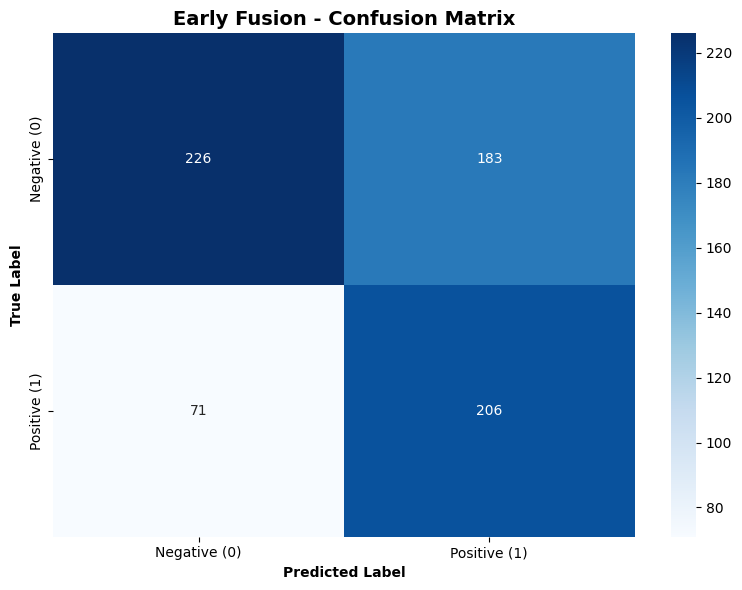


Detailed Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

Negative (0)     0.7609    0.5526    0.6402       409
Positive (1)     0.5296    0.7437    0.6186       277

    accuracy                         0.6297       686
   macro avg     0.6453    0.6481    0.6294       686
weighted avg     0.6675    0.6297    0.6315       686



In [11]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Early Fusion - Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetailed Classification Report:")
print("-"*70)
print(classification_report(test_labels, test_preds, 
                          target_names=['Negative (0)', 'Positive (1)'],
                          digits=4))